# Core Harmony Batch-Effect Diagnostic

This notebook tests Harmony correction across inferred Xenium cores without changing the default pipeline outputs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import scanpy as sc
import scanpy.external as sce

CURRENT_DIRECTORY = Path.cwd().resolve()
PIPELINE_ROOT = (
    CURRENT_DIRECTORY.parent
    if (CURRENT_DIRECTORY.parent / "src").exists()
    else CURRENT_DIRECTORY
)
PROJECT_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from src.config import Configuration

CONFIG_PATH = PROJECT_ROOT / "configs" / "debug.yaml"
BATCH_KEY = "core_id"
MAX_CELLS_PER_CORE = 5000
RANDOM_STATE = 0

def compute_harmony_umap_diagnostic(
    annotated_data,
    batch_key: str,
    pca_n_components: int,
    adjusted_basis: str = "X_pca_harmony_diagnostic",
    uncorrected_umap_key: str = "X_umap_uncorrected_diagnostic",
    corrected_umap_key: str = "X_umap_harmony_diagnostic",
) -> None:
    """Compute before/after Harmony UMAPs for this diagnostic notebook."""

    if batch_key not in annotated_data.obs.columns:
        raise ValueError(f"{batch_key!r} not found in obs")
    if annotated_data.obs[batch_key].nunique() < 2:
        raise ValueError(f"{batch_key!r} must contain at least two groups")

    sc.pp.pca(annotated_data, n_comps=pca_n_components)
    sc.pp.neighbors(annotated_data, use_rep="X_pca", metric="cosine")
    sc.tl.umap(annotated_data)
    annotated_data.obsm[uncorrected_umap_key] = annotated_data.obsm["X_umap"].copy()

    sce.pp.harmony_integrate(
        annotated_data,
        key=batch_key,
        adjusted_basis=adjusted_basis,
    )
    sc.pp.neighbors(annotated_data, use_rep=adjusted_basis, metric="cosine")
    sc.tl.umap(annotated_data)
    annotated_data.obsm[corrected_umap_key] = annotated_data.obsm["X_umap"].copy()


In [2]:
configuration = Configuration()
configuration.load_from_yaml(CONFIG_PATH)
configuration.create_directories()

adata = sc.read_h5ad(
    configuration.processed_data_directory / "processed.h5ad",
    backed="r",
)
adata

AnnData object with n_obs × n_vars = 148441 × 4569 backed at '/vast/projects/nzh/wharton/rohit/output/debug/processed/processed.h5ad'
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'core_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'leiden', 'cell_type', 'spatial_domain', 'spatial_domain_label'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatial_neighbors', 'uma

In [3]:
if BATCH_KEY not in adata.obs:
    raise ValueError(
        "core_id is missing. Run the ingest stage after the core-labeling update."
    )

adata.obs[["sample_id", BATCH_KEY]].value_counts().sort_index()

sample_id  core_id       
50702-2    50702-2_core_1    44371
           50702-2_core_2    55764
           50702-2_core_3    48306
Name: count, dtype: int64

In [4]:
sampled_obs_names = []
for _, group in adata.obs.groupby(BATCH_KEY, observed=True):
    sampled = group.sample(
        n=min(MAX_CELLS_PER_CORE, len(group)),
        random_state=RANDOM_STATE,
    )
    sampled_obs_names.extend(sampled.index.tolist())

diagnostic = adata[sampled_obs_names].to_memory()
compute_harmony_umap_diagnostic(
    diagnostic,
    batch_key=BATCH_KEY,
    pca_n_components=configuration.pipeline.pca_n_components,
)
diagnostic

/vast/projects/nzh/wharton/rohit/pipeline/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-15 11:52:17,755 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-06-15 11:52:30,987 - harmonypy - INFO - sklearn.KMeans initialization complete.


2026-06-15 11:52:31,406 - harmonypy - INFO - Iteration 1 of 10


2026-06-15 11:52:37,011 - harmonypy - INFO - Iteration 2 of 10


...

2026-06-15 11:52:49,413 - harmonypy - INFO - Iteration 5 of 10


2026-06-15 11:52:53,922 - harmonypy - INFO - Iteration 6 of 10


2026-06-15 11:52:57,522 - harmonypy - INFO - Iteration 7 of 10


2026-06-15 11:52:59,892 - harmonypy - INFO - Converged after 7 iterations


AnnData object with n_obs × n_vars = 15000 × 4569
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'core_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'leiden', 'cell_type', 'spatial_domain', 'spatial_domain_label'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'neighborhood_composition', 'spatial', 'X_umap_uncor

PosixPath('/vast/projects/nzh/wharton/rohit/output/debug/figures/core_harmony_umap_before_after.png')

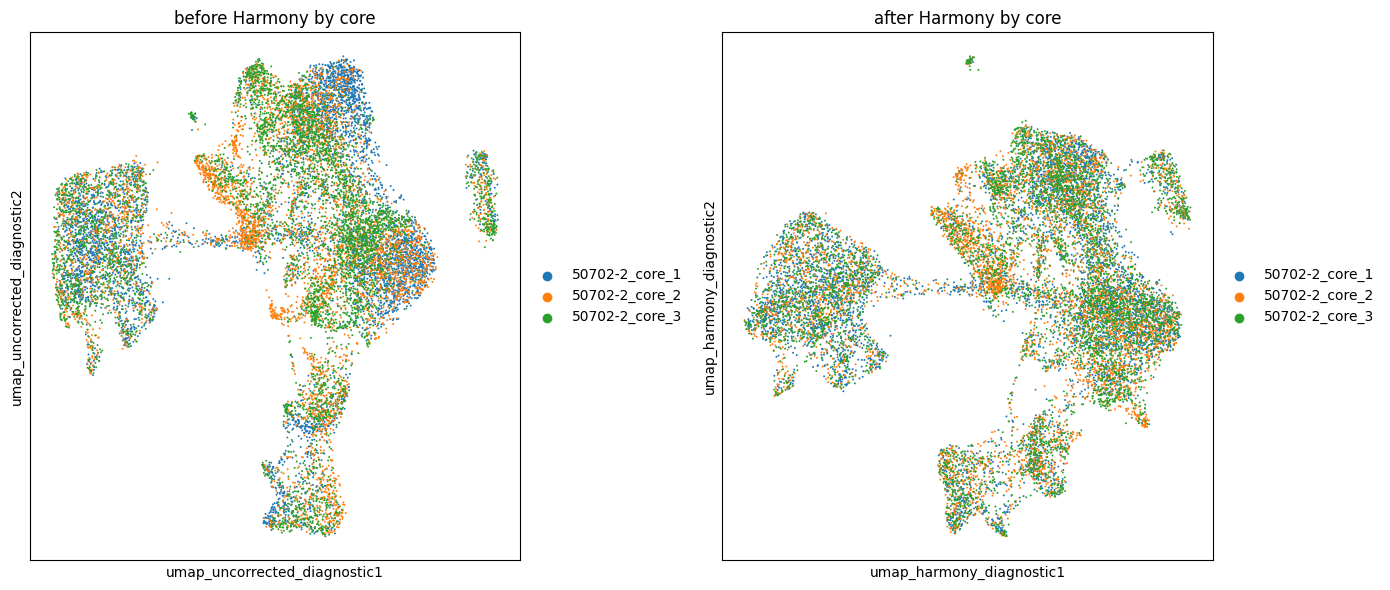

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(
    diagnostic,
    basis="umap_uncorrected_diagnostic",
    color=BATCH_KEY,
    ax=axes[0],
    show=False,
    title="before Harmony by core",
)
sc.pl.embedding(
    diagnostic,
    basis="umap_harmony_diagnostic",
    color=BATCH_KEY,
    ax=axes[1],
    show=False,
    title="after Harmony by core",
)
fig.tight_layout()
core_plot_path = configuration.figures_directory / "core_harmony_umap_before_after.png"
fig.savefig(core_plot_path, dpi=200, bbox_inches="tight")
core_plot_path

PosixPath('/vast/projects/nzh/wharton/rohit/output/debug/figures/core_harmony_umap_by_sample_before_after.png')

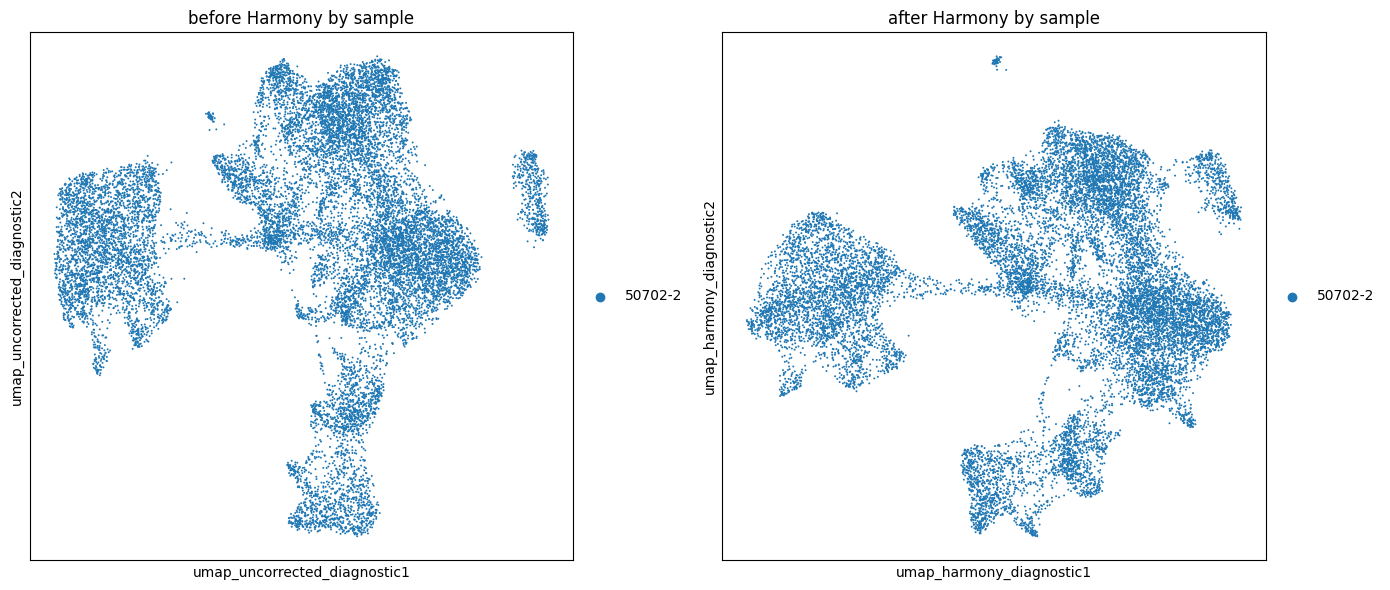

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(
    diagnostic,
    basis="umap_uncorrected_diagnostic",
    color="sample_id",
    ax=axes[0],
    show=False,
    title="before Harmony by sample",
)
sc.pl.embedding(
    diagnostic,
    basis="umap_harmony_diagnostic",
    color="sample_id",
    ax=axes[1],
    show=False,
    title="after Harmony by sample",
)
fig.tight_layout()
sample_plot_path = configuration.figures_directory / "core_harmony_umap_by_sample_before_after.png"
fig.savefig(sample_plot_path, dpi=200, bbox_inches="tight")
sample_plot_path

In [7]:
diagnostic.obs.groupby(["sample_id", BATCH_KEY], observed=True)[
    ["total_counts", "log1p_total_counts"]
].median()

total_counts  log1p_total_counts
sample_id core_id                                         
50702-2   50702-2_core_1         401.0            5.996452
          50702-2_core_2         315.0            5.755742
          50702-2_core_3         360.0            5.888878